# PyTorch DataLoader

## 事前準備

In [1]:
import torch

# GPUが使えるか確認してデバイスを設定
# NOTE: `x = x.to(device) ` とすることで対象のデバイスに切り替え可能
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
from typing import Callable

import random
import torch
import numpy as np


# シード値の固定
# NOTE: 戻り値はDataLoaderのシード固定に使用する。　
# 　　　　　　　　　　　　(ex) loader = DataLoader(..., worker_init_fn=seed_worker, generator=generator)
def fixing_seed(seed: int=42) -> tuple[torch.Generator, Callable]:
    # Python のシード固定
    random.seed(seed)
    # Numpy のシード固定
    np.random.seed(seed)
    # PyTorch のシード固定
    torch.manual_seed(seed)
    # CUDA の再現性確保の設定
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    # DataLoader 各ワーカー用の初期化関数
    def seed_worker_fn(worker_id: int) -> None:
        # 各 worker で Python / NumPy も固定
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    # DataLoader の乱数源
    generator = torch.Generator()
    generator.manual_seed(seed)

    return generator, seed_worker_fn

In [3]:
SEED = 24

torch_generator, seed_worker_fn = fixing_seed(SEED)

## DataLoader

In [4]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

### MNISTデータセット取得

In [ ]:
# 画像幅、高さ
IMG_SIZE = 28

# 訓練データ
mnist_train = MNIST(
    "../../.cache/data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# 検証データ
mnist_test = MNIST(
    "../../.cache/data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print(f"n_train: {len(mnist_train)}, n_test: {len(mnist_test)}")

n_train: 60000, n_test: 10000


### DataLoaderの設定

In [6]:
BATCH_SIZE = 128

train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True, generator=torch_generator, worker_init_fn=seed_worker_fn)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False, generator=torch_generator, worker_init_fn=seed_worker_fn)

### モデル構築

In [7]:
class Network(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(IMG_SIZE * IMG_SIZE, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, IMG_SIZE * IMG_SIZE)     # 画像を1次元に変換
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [8]:
model = Network()
model.to(device)

Network(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)

### 学習

#### ハイパーパラメータ

In [9]:
LR = 0.01
N_EPOCHS = 10

VERBOSE  = 1

#### 学習処理

In [10]:
%%time
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)

record_train_loss = []
record_test_loss = []

for epoch in tqdm(range(N_EPOCHS)):
    model.train()     # 訓練モード
    train_loss = 0

    # ミニバッチ取得(train)
    for x, t in train_loader:
        x, t = x.to(device), t.to(device)
        y = model(x)

        loss = loss_func(y, t)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)
    record_train_loss.append(train_loss)

    model.eval()  # 評価モード
    test_loss = 0

    # ミニバッチ取得(test)
    for x, t in test_loader:
        x, t = x.to(device), t.to(device)
        y = model(x)

        loss = loss_func(y, t)
        test_loss += loss.item()

    test_loss /= len(test_loader)
    record_test_loss.append(test_loss)

    if epoch % VERBOSE == 0:
        print(f"Epoch: {epoch}, train_loss: {train_loss}, test_loss: {test_loss}")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0, train_loss: 2.0428401851959066, test_loss: 1.4896694542486457
Epoch: 1, train_loss: 0.9454827889450578, test_loss: 0.6117384475243243
Epoch: 2, train_loss: 0.5306071229835054, test_loss: 0.4407739358235009
Epoch: 3, train_loss: 0.42450394324148133, test_loss: 0.3779508383779586
Epoch: 4, train_loss: 0.3756100297418993, test_loss: 0.3418896958420548
Epoch: 5, train_loss: 0.3460538130579218, test_loss: 0.3180379897733278
Epoch: 6, train_loss: 0.32465850986016076, test_loss: 0.2996566154628615
Epoch: 7, train_loss: 0.3079270147311408, test_loss: 0.28688903310913827
Epoch: 8, train_loss: 0.2937535122513517, test_loss: 0.2762055012244212
Epoch: 9, train_loss: 0.2813211515196351, test_loss: 0.26502716765279255
CPU times: user 26.2 s, sys: 842 ms, total: 27.1 s
Wall time: 25.8 s


### 評価

#### 誤差の推移

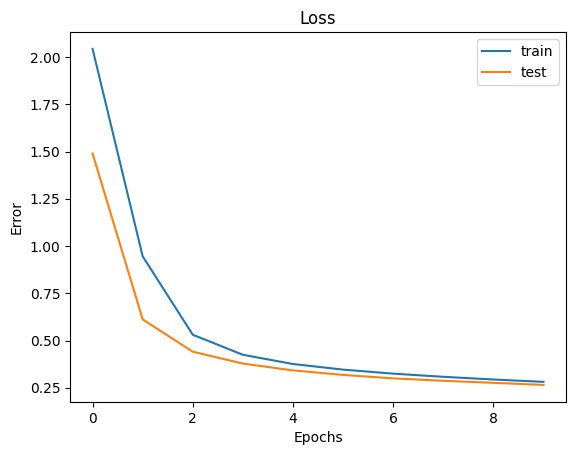

In [11]:
plt.plot(record_train_loss, label="train")
plt.plot(record_test_loss, label="test")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

#### 正答率算出

In [12]:
correct = 0
total = 0

model.eval()

for i, (x, t) in enumerate(test_loader):
    x, t = x.to(device), t.to(device)
    y = model(x)

    correct += (y.argmax(1) == t).sum().item()
    total += len(x)

print(f"Accuracy: {correct / total}")

Accuracy: 0.9241
